<a href="https://colab.research.google.com/github/modelpredection-glitch/injector-website/blob/main/Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob
import numpy as np

# Reading files of faulty and healthy and classify 1,0 resp. Then putting it in same dataframe as df

# Faulty Data (Label = 1)
file_paths = glob.glob("/content/drive/MyDrive/Data/Train Data/Faulty/*.csv")
dfs = [pd.read_csv(file) for file in file_paths]
f_df = pd.concat(dfs, ignore_index=True, sort=False)
f_df['classifier'] = 1

# Healthy Data (Label = 0)
file_paths = glob.glob("/content/drive/MyDrive/Data/Train Data/Healthy/*.csv")
dfs = [pd.read_csv(file) for file in file_paths]
h_df = pd.concat(dfs, ignore_index=True, sort=False)
h_df['classifier'] = 0


In [ ]:
# List of features
related_features = [
    'Accelerator Pedal Position (APP)',
    'Boost Pressure',
    'Cylinder 1 Fuel Compensation',
    'Cylinder 2 Fuel Compensation',
    'Cylinder 3 Fuel Compensation',
    'Cylinder 4 Fuel Compensation',
    'Desired Fuel Injection Quantity',
    'Desired Fuel Rail Pressure (FRP)',
    'Desired Mass Air Flow (MAF)',
    'Engine Speed',
    'Fuel Rail Pressure (FRP)',
    'Fuel Temperature',
    'Intake Air Temperature (IAT)',
    'Mass Air Flow (MAF)',
    'Main Fuel Injection Quantity',
    'Pre Fuel Injection Quantity',
    'Barometric Pressure (BARO)','Intake Air Temperature',
    'classifier'
]

In [ ]:
# Set ranges for the new features
intake_air_temp_range = (30, 50)   # Intake air temperature in °C (example range)

# Add random values to the DataFrame
f_df['Intake Air Temperature'] = np.random.uniform(intake_air_temp_range[0], intake_air_temp_range[1], size=len(f_df))

# Optional: round to 1 decimal place
f_df['Intake Air Temperature'] = f_df['Intake Air Temperature'].round(1)

# Add random values to the DataFrame
h_df['Intake Air Temperature'] = np.random.uniform(intake_air_temp_range[0], intake_air_temp_range[1], size=len(h_df))

# Optional: round to 1 decimal place
h_df['Intake Air Temperature'] = h_df['Intake Air Temperature'].round(1)

In [ ]:
# Select only the relevant features for analysis from healthy and faulty datasets
# This ensures both datasets have the same columns and order
h_df = h_df[related_features]  # Healthy dataset
f_df = f_df[related_features]  # Faulty dataset

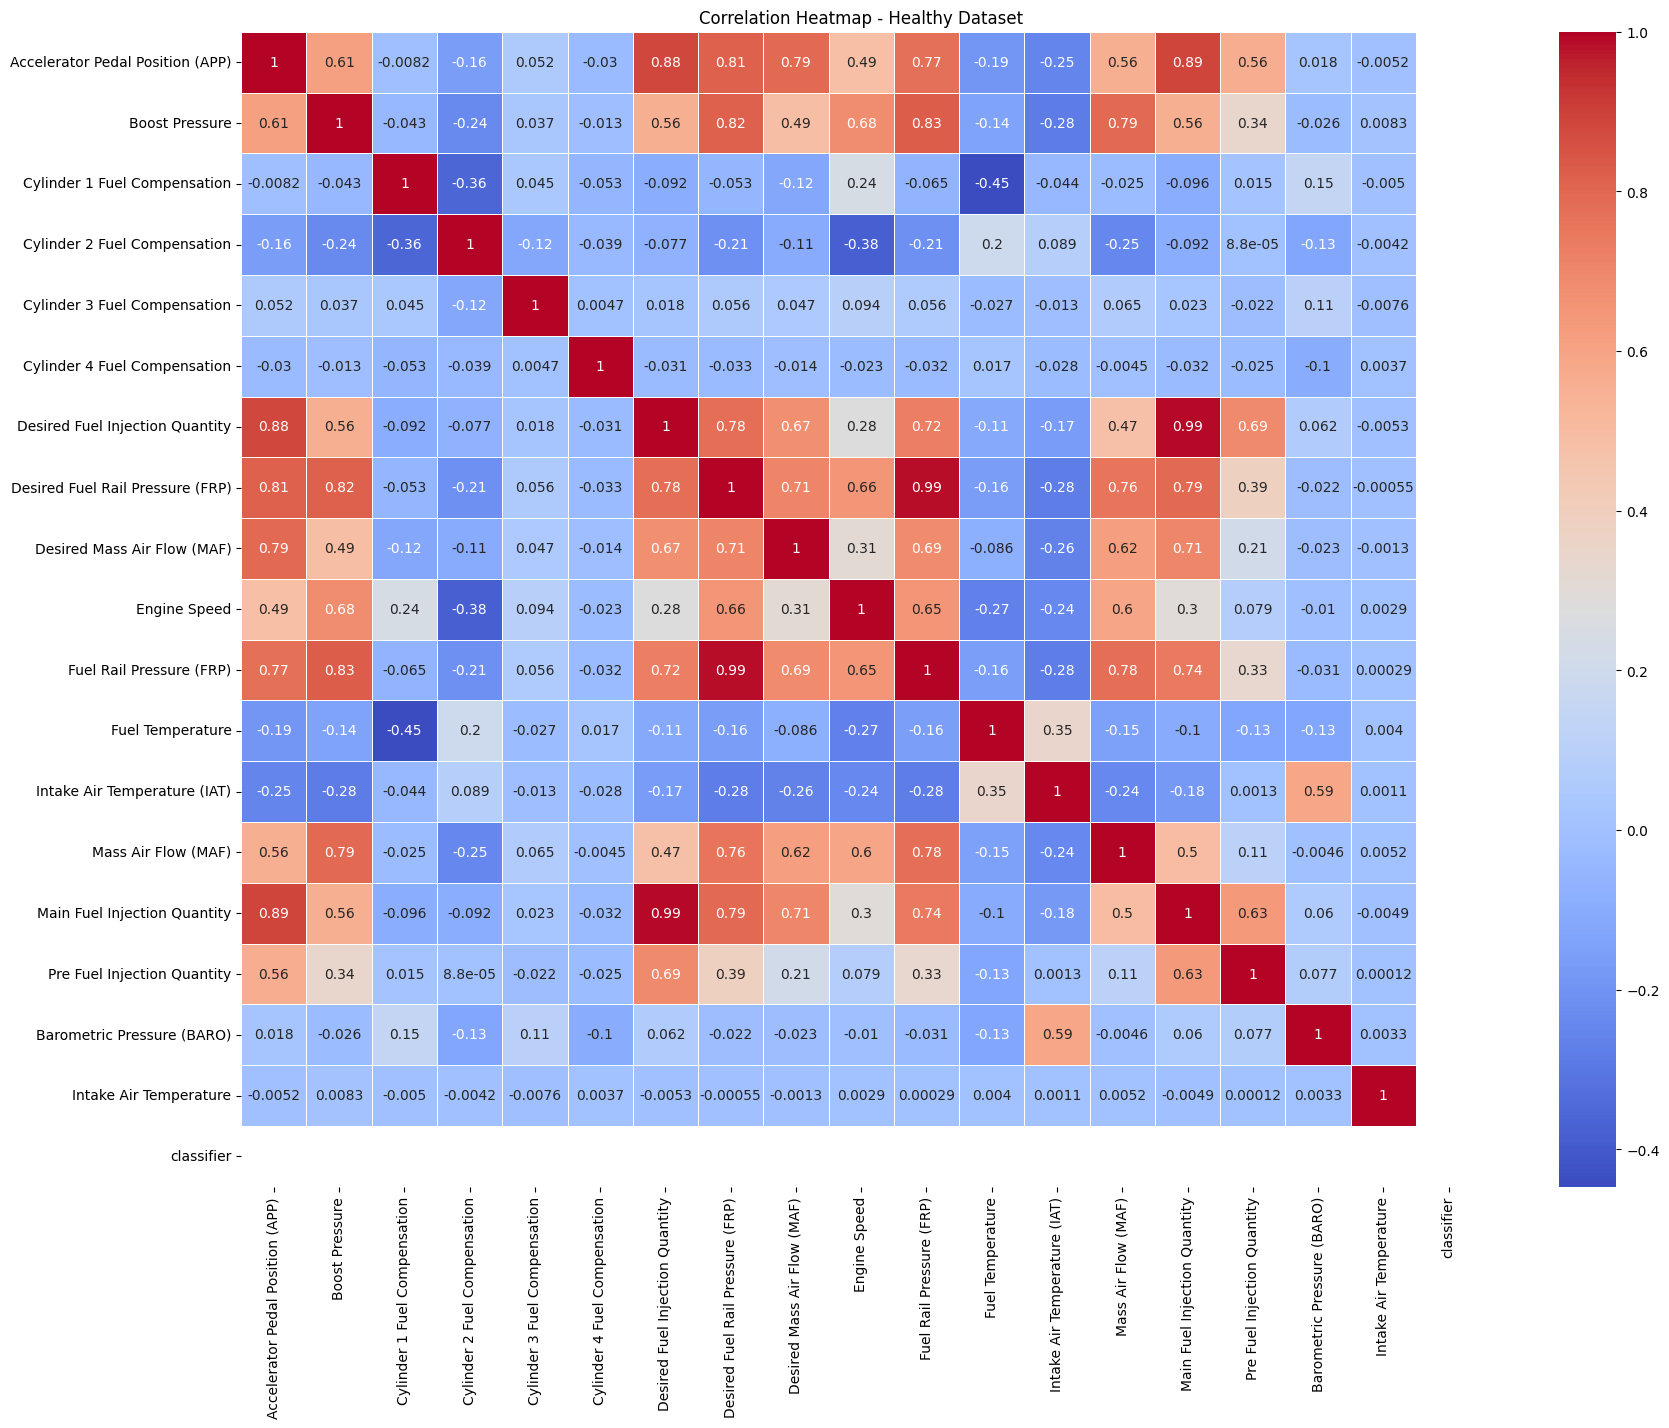

In [ ]:
# Plotting heatmap of important features for healthy dataset (h_df)

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix_healthy = h_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix_healthy,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Healthy Dataset")
plt.show()

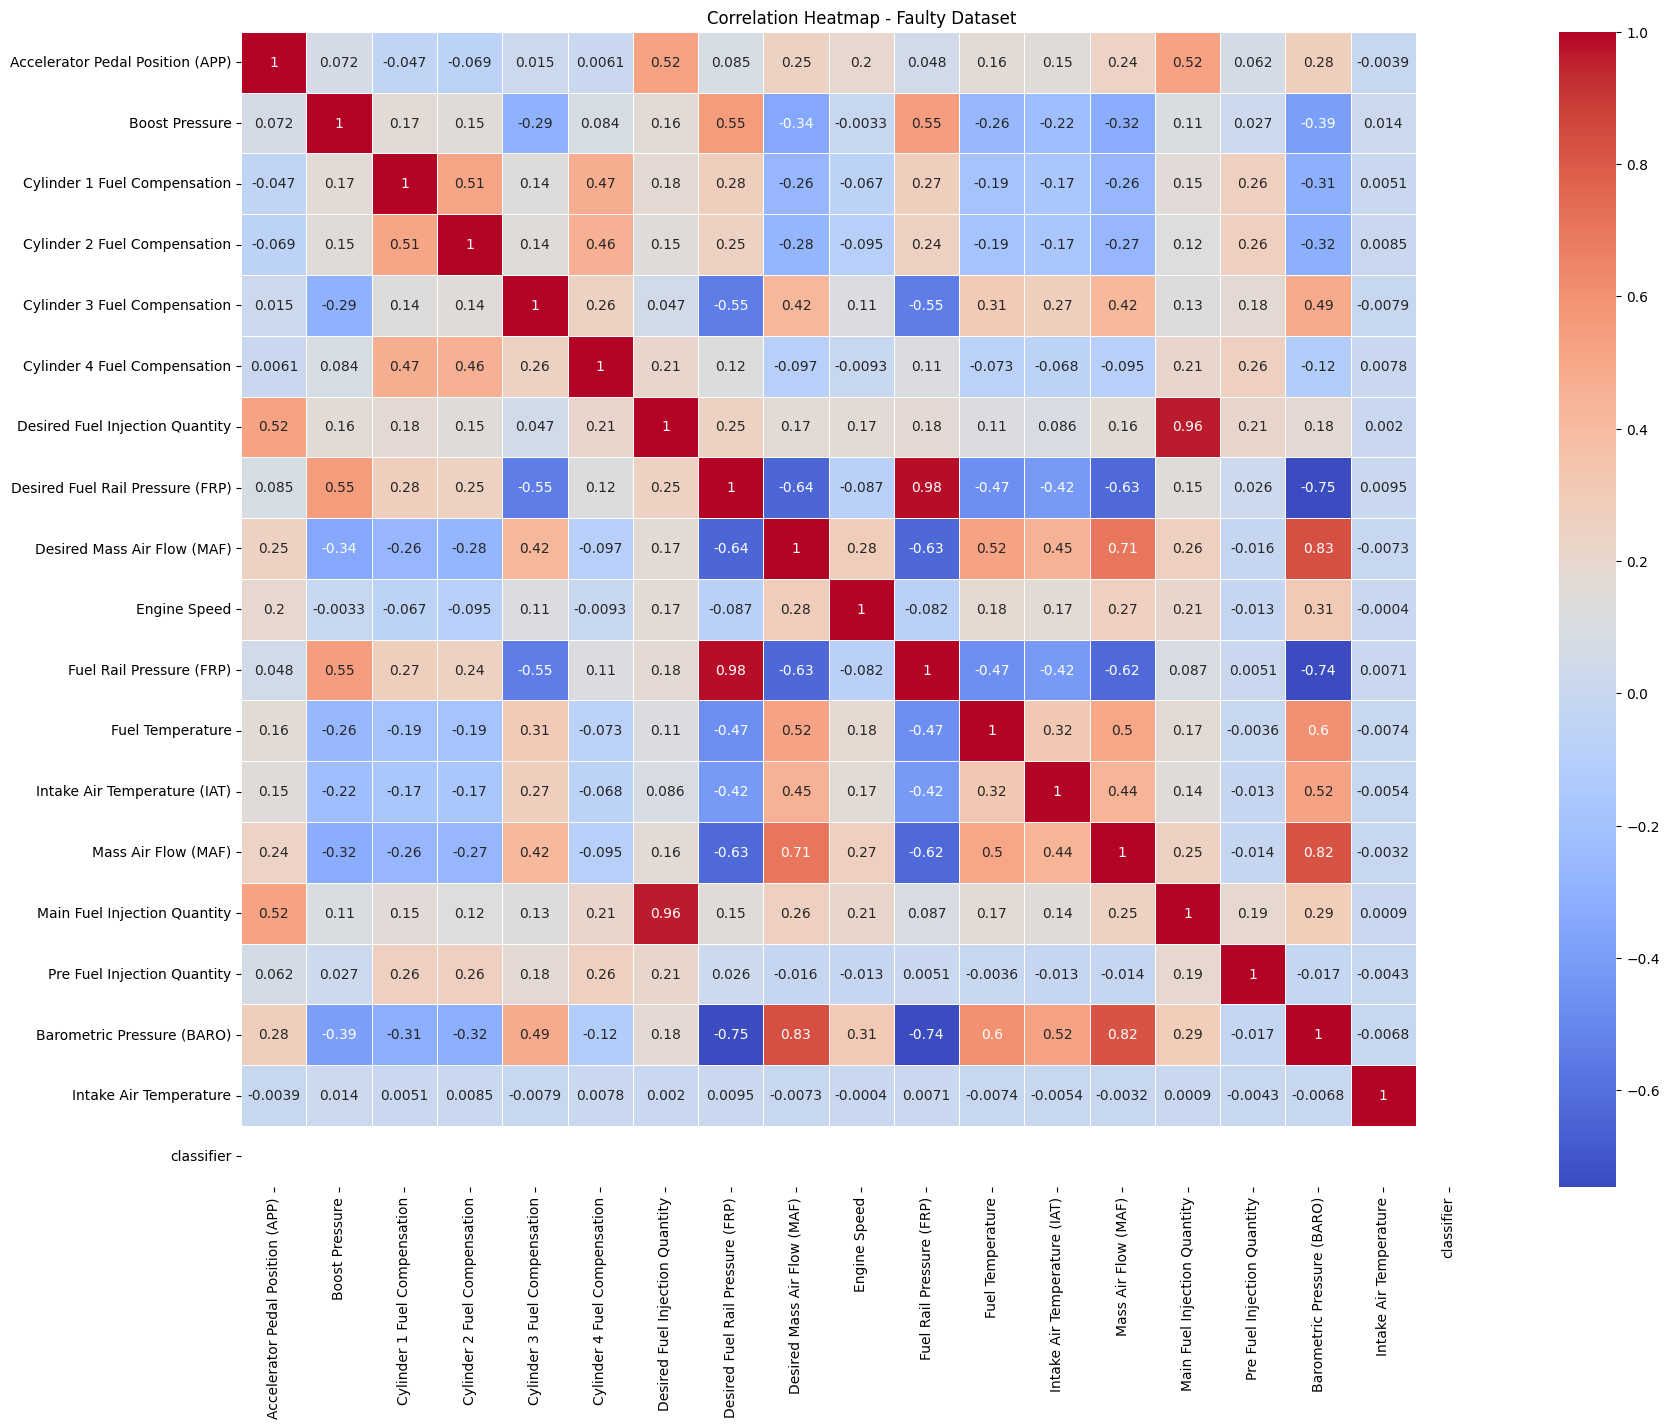

In [ ]:
# Plotting heatmap of important features for Faulty dataset (f_df)

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix_faulty = f_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix_faulty,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Faulty Dataset")
plt.show()

In [ ]:
# Define the list of selected features including the target column
Features = [
    'Desired Fuel Injection Quantity',
    'Desired Fuel Rail Pressure (FRP)',
    'Desired Mass Air Flow (MAF)',
    'Fuel Rail Pressure (FRP)',
    'Mass Air Flow (MAF)',
    'Main Fuel Injection Quantity',
    'Pre Fuel Injection Quantity',
    'Engine Speed',
    'Boost Pressure','Fuel Temperature','Intake Air Temperature',
    'classifier'  # Target column
]

# Separate feature columns from the target column
colu = Features[:-1]  # All columns except 'classifier'

In [ ]:
# Select only the defined features from healthy and faulty datasets
h_df = h_df[Features]  # Healthy dataset
f_df = f_df[Features]  # Faulty dataset

# Combine healthy and faulty datasets into a single DataFrame
df = pd.concat([f_df, h_df], ignore_index=True, sort=False)

In [ ]:
# Save the combined dataset to a CSV file
df.to_csv("/content/drive/MyDrive/Data/Train Data/df.csv", index=False)

print("Combined dataset saved successfully!")

Combined dataset saved successfully!


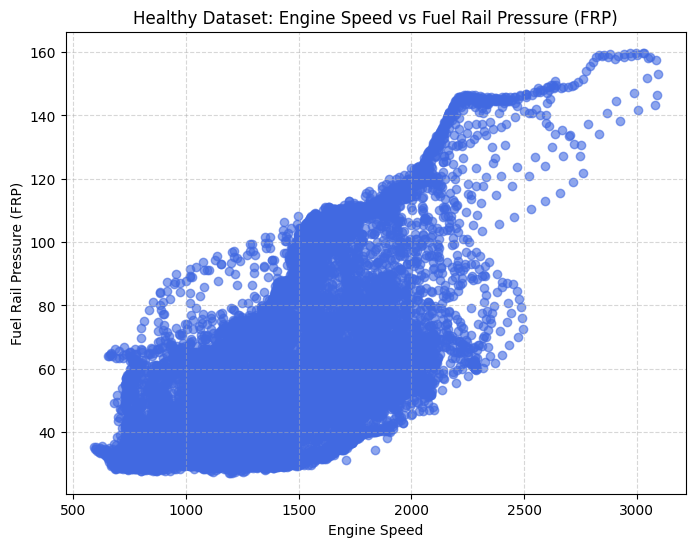

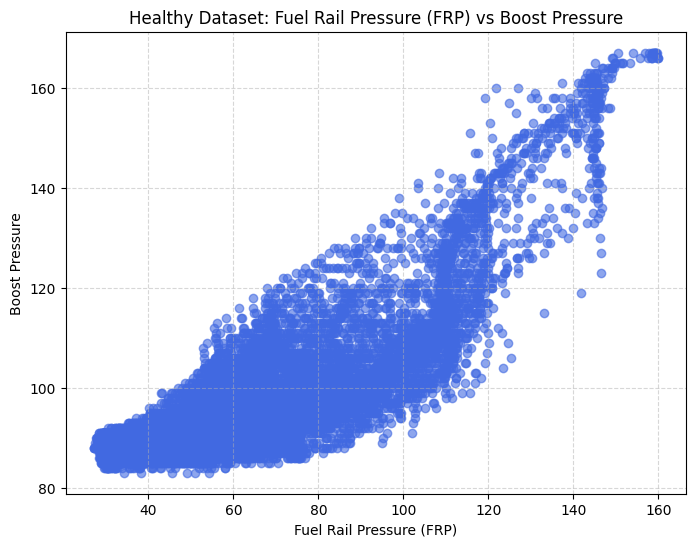

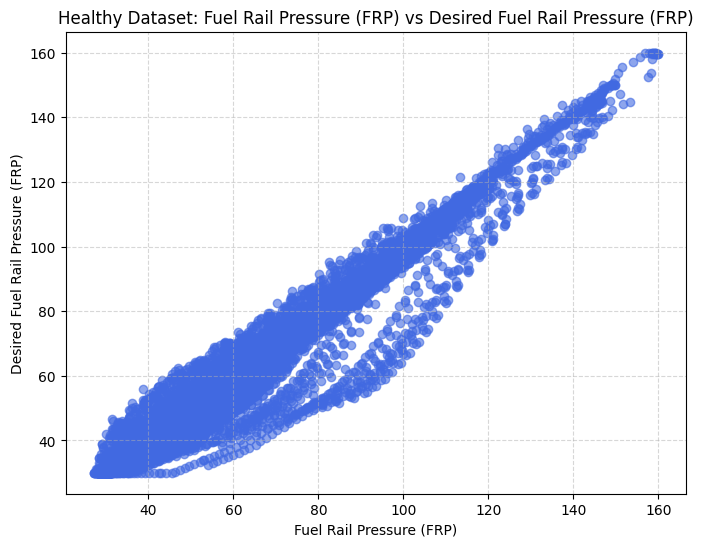

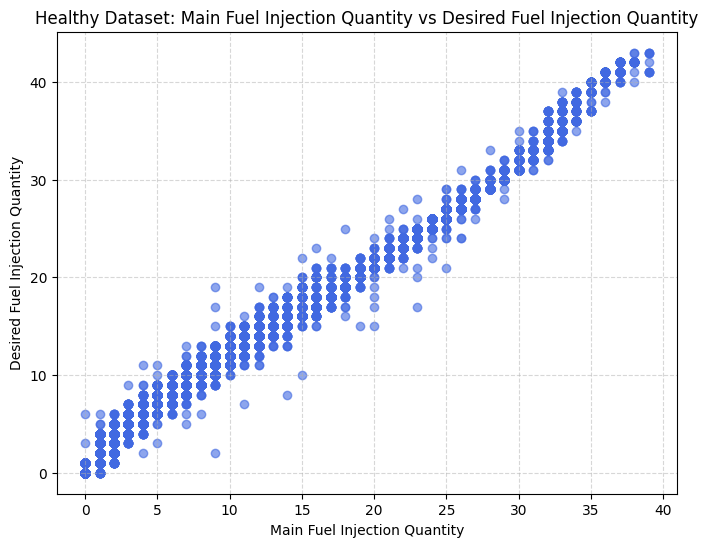

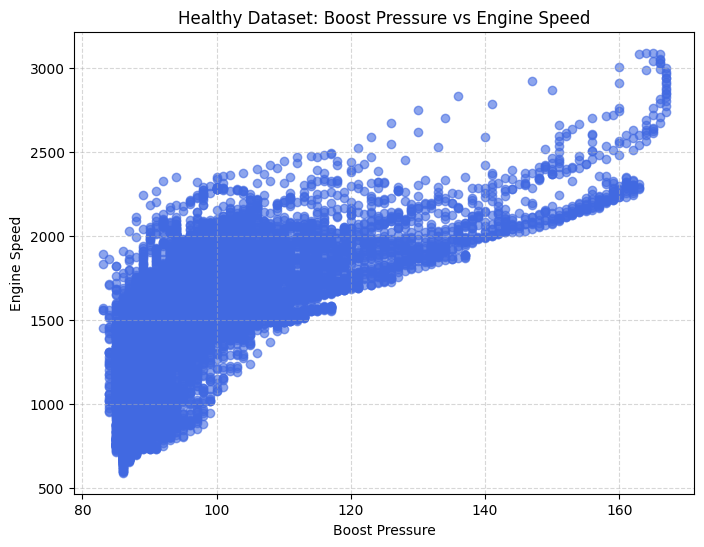

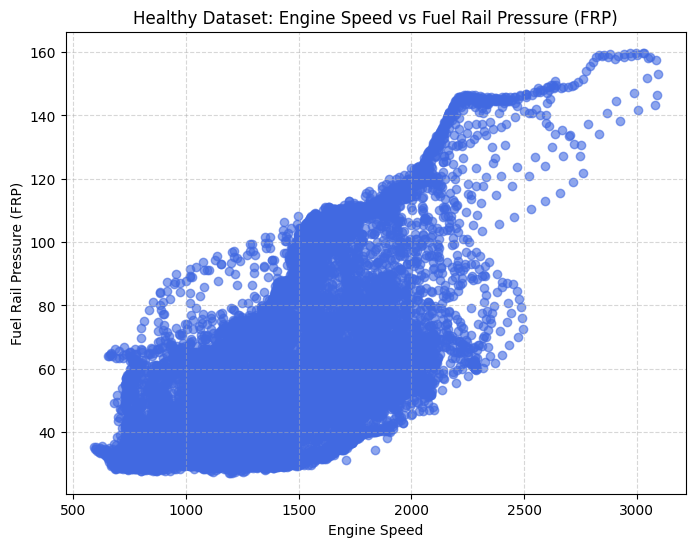

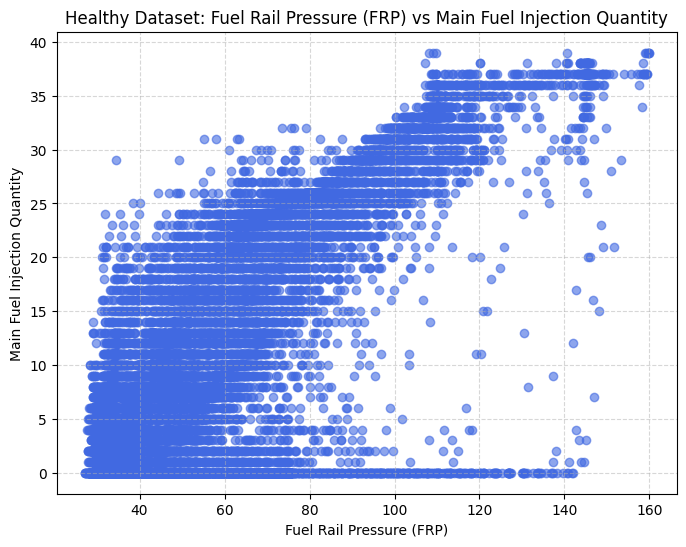

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# Specific Pairwise Scatter Plots for Healthy Dataset
# ==============================
feature_pairs = [
    ('Engine Speed', 'Fuel Rail Pressure (FRP)'),
    ('Fuel Rail Pressure (FRP)', 'Boost Pressure'),
    ('Fuel Rail Pressure (FRP)', 'Desired Fuel Rail Pressure (FRP)'),
    ('Main Fuel Injection Quantity', 'Desired Fuel Injection Quantity'),
    ('Boost Pressure', 'Engine Speed'),
    ('Engine Speed', 'Fuel Rail Pressure (FRP)'),
    ('Fuel Rail Pressure (FRP)', 'Main Fuel Injection Quantity')
]

for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(8,6))
    plt.scatter(
        h_df[x_feature],
        h_df[y_feature],
        color='royalblue',
        alpha=0.6
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f'Healthy Dataset: {x_feature} vs {y_feature}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

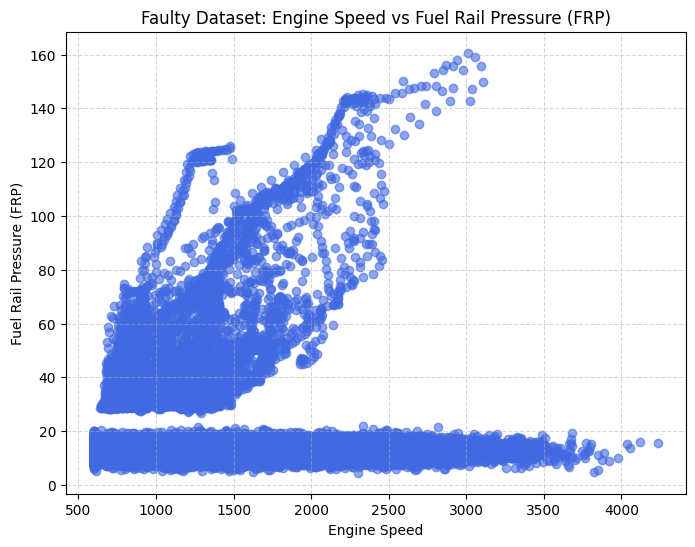

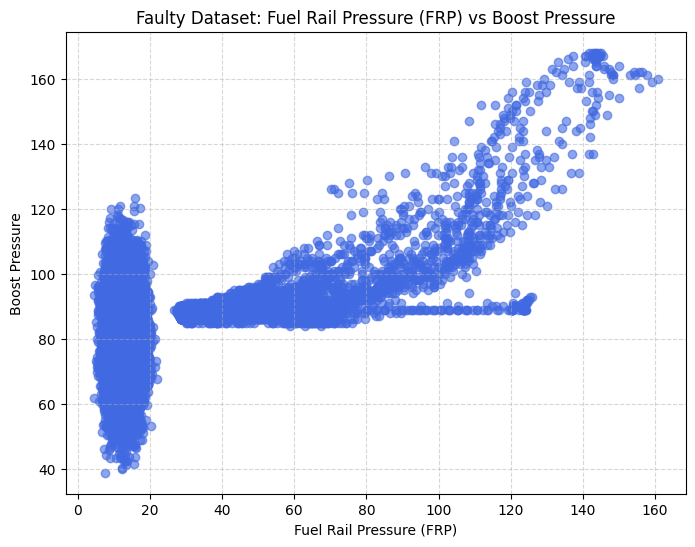

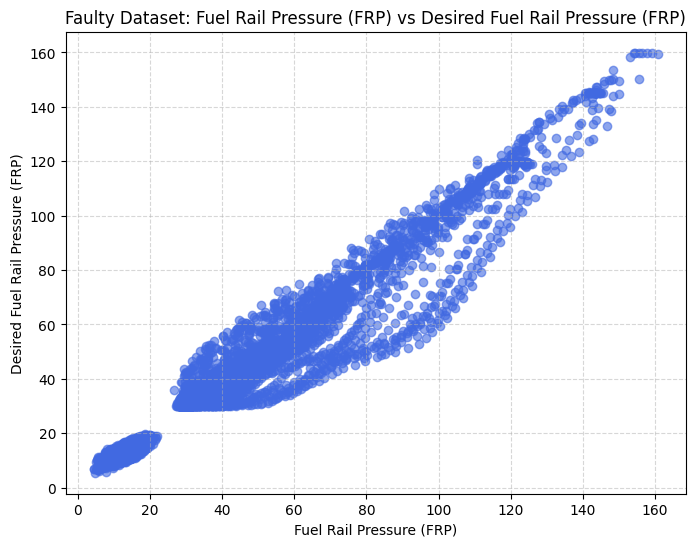

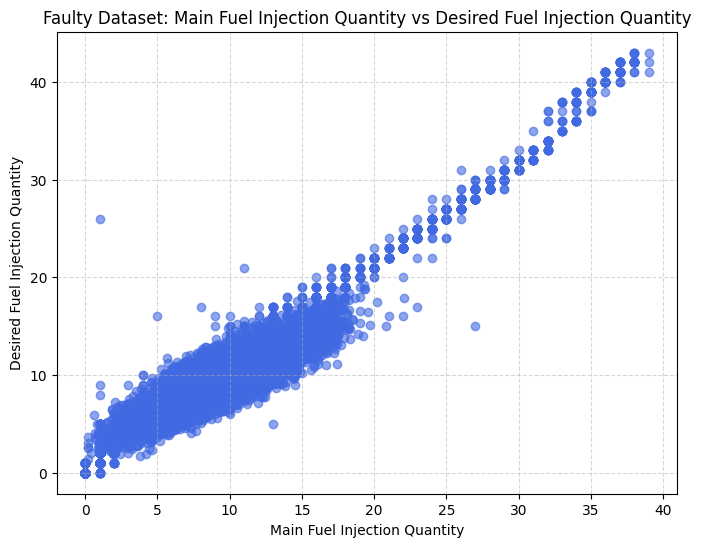

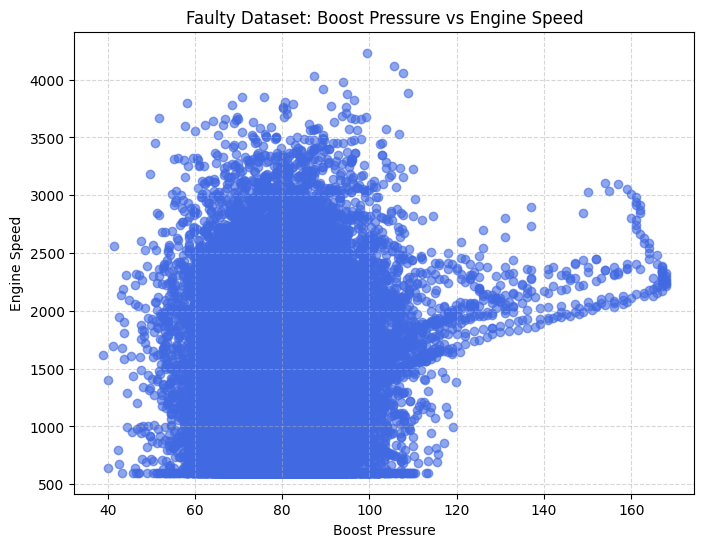

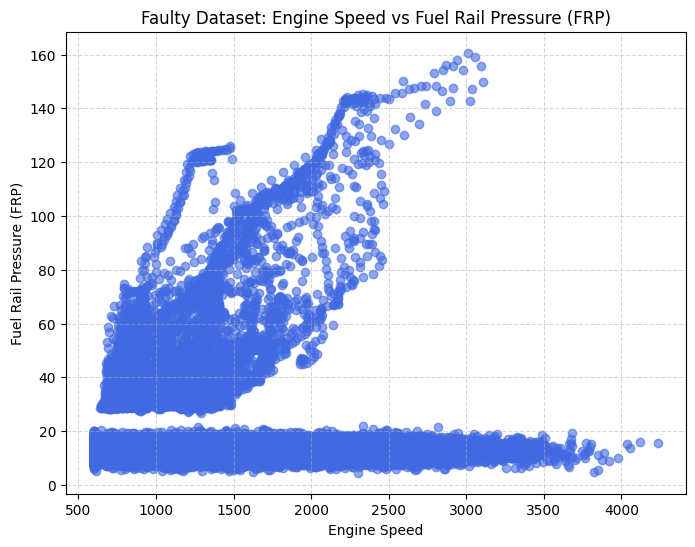

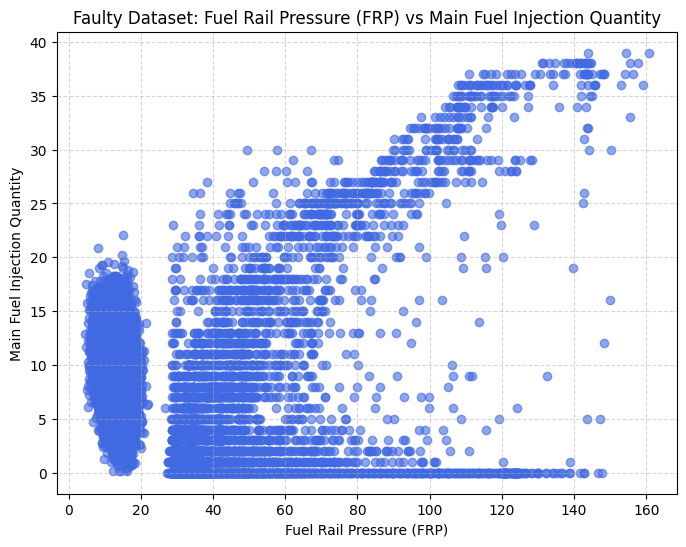

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# Specific Pairwise Scatter Plots for Faulty Dataset
# ==============================
feature_pairs = [
    ('Engine Speed', 'Fuel Rail Pressure (FRP)'),
    ('Fuel Rail Pressure (FRP)', 'Boost Pressure'),
    ('Fuel Rail Pressure (FRP)', 'Desired Fuel Rail Pressure (FRP)'),
    ('Main Fuel Injection Quantity', 'Desired Fuel Injection Quantity'),
    ('Boost Pressure', 'Engine Speed'),
    ('Engine Speed', 'Fuel Rail Pressure (FRP)'),
    ('Fuel Rail Pressure (FRP)', 'Main Fuel Injection Quantity')
]

for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(8,6))
    plt.scatter(
        f_df[x_feature],
        f_df[y_feature],
        color='royalblue',
        alpha=0.6
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f'Faulty Dataset: {x_feature} vs {y_feature}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [ ]:
h_df = h_df.drop(columns=['classifier'])
f_df = f_df.drop(columns=['classifier'])

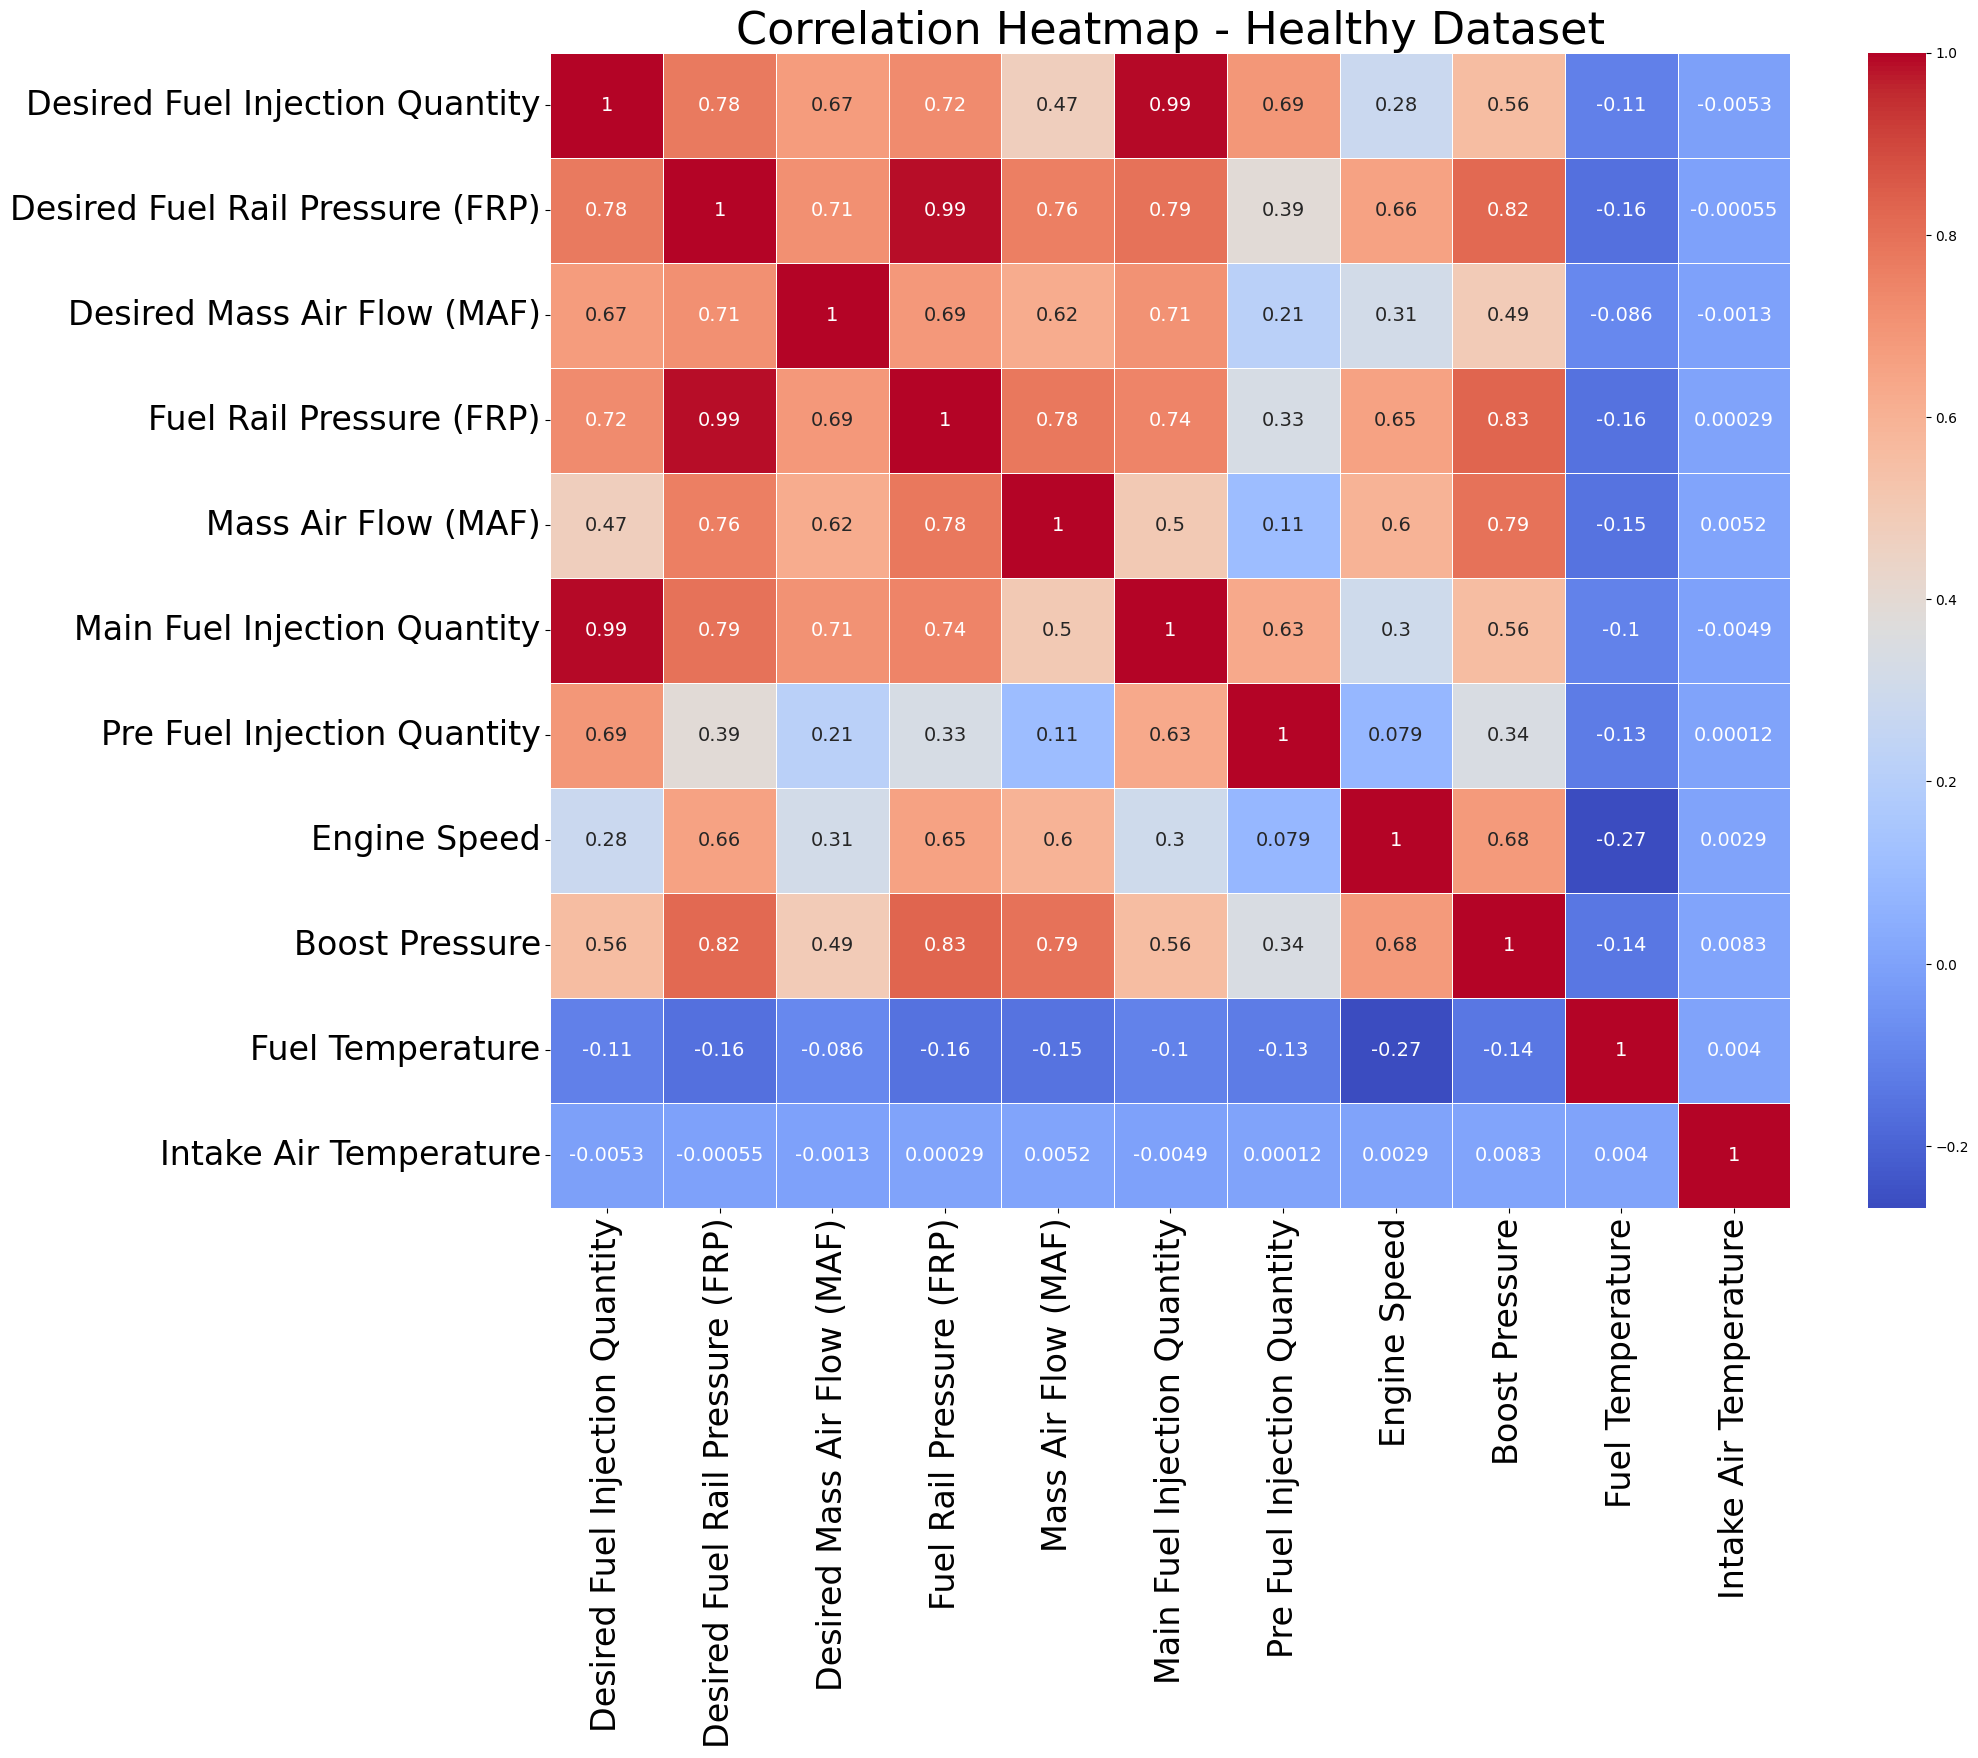

In [ ]:
# Plotting heatmap of important features for healthy dataset (h_df)

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix_healthy = h_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix_healthy,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":14}
)

# Increase axis label size
plt.xticks(fontsize=24, rotation=90)
plt.yticks(fontsize=24)
plt.title("Correlation Heatmap - Healthy Dataset", fontsize=32)
plt.show()

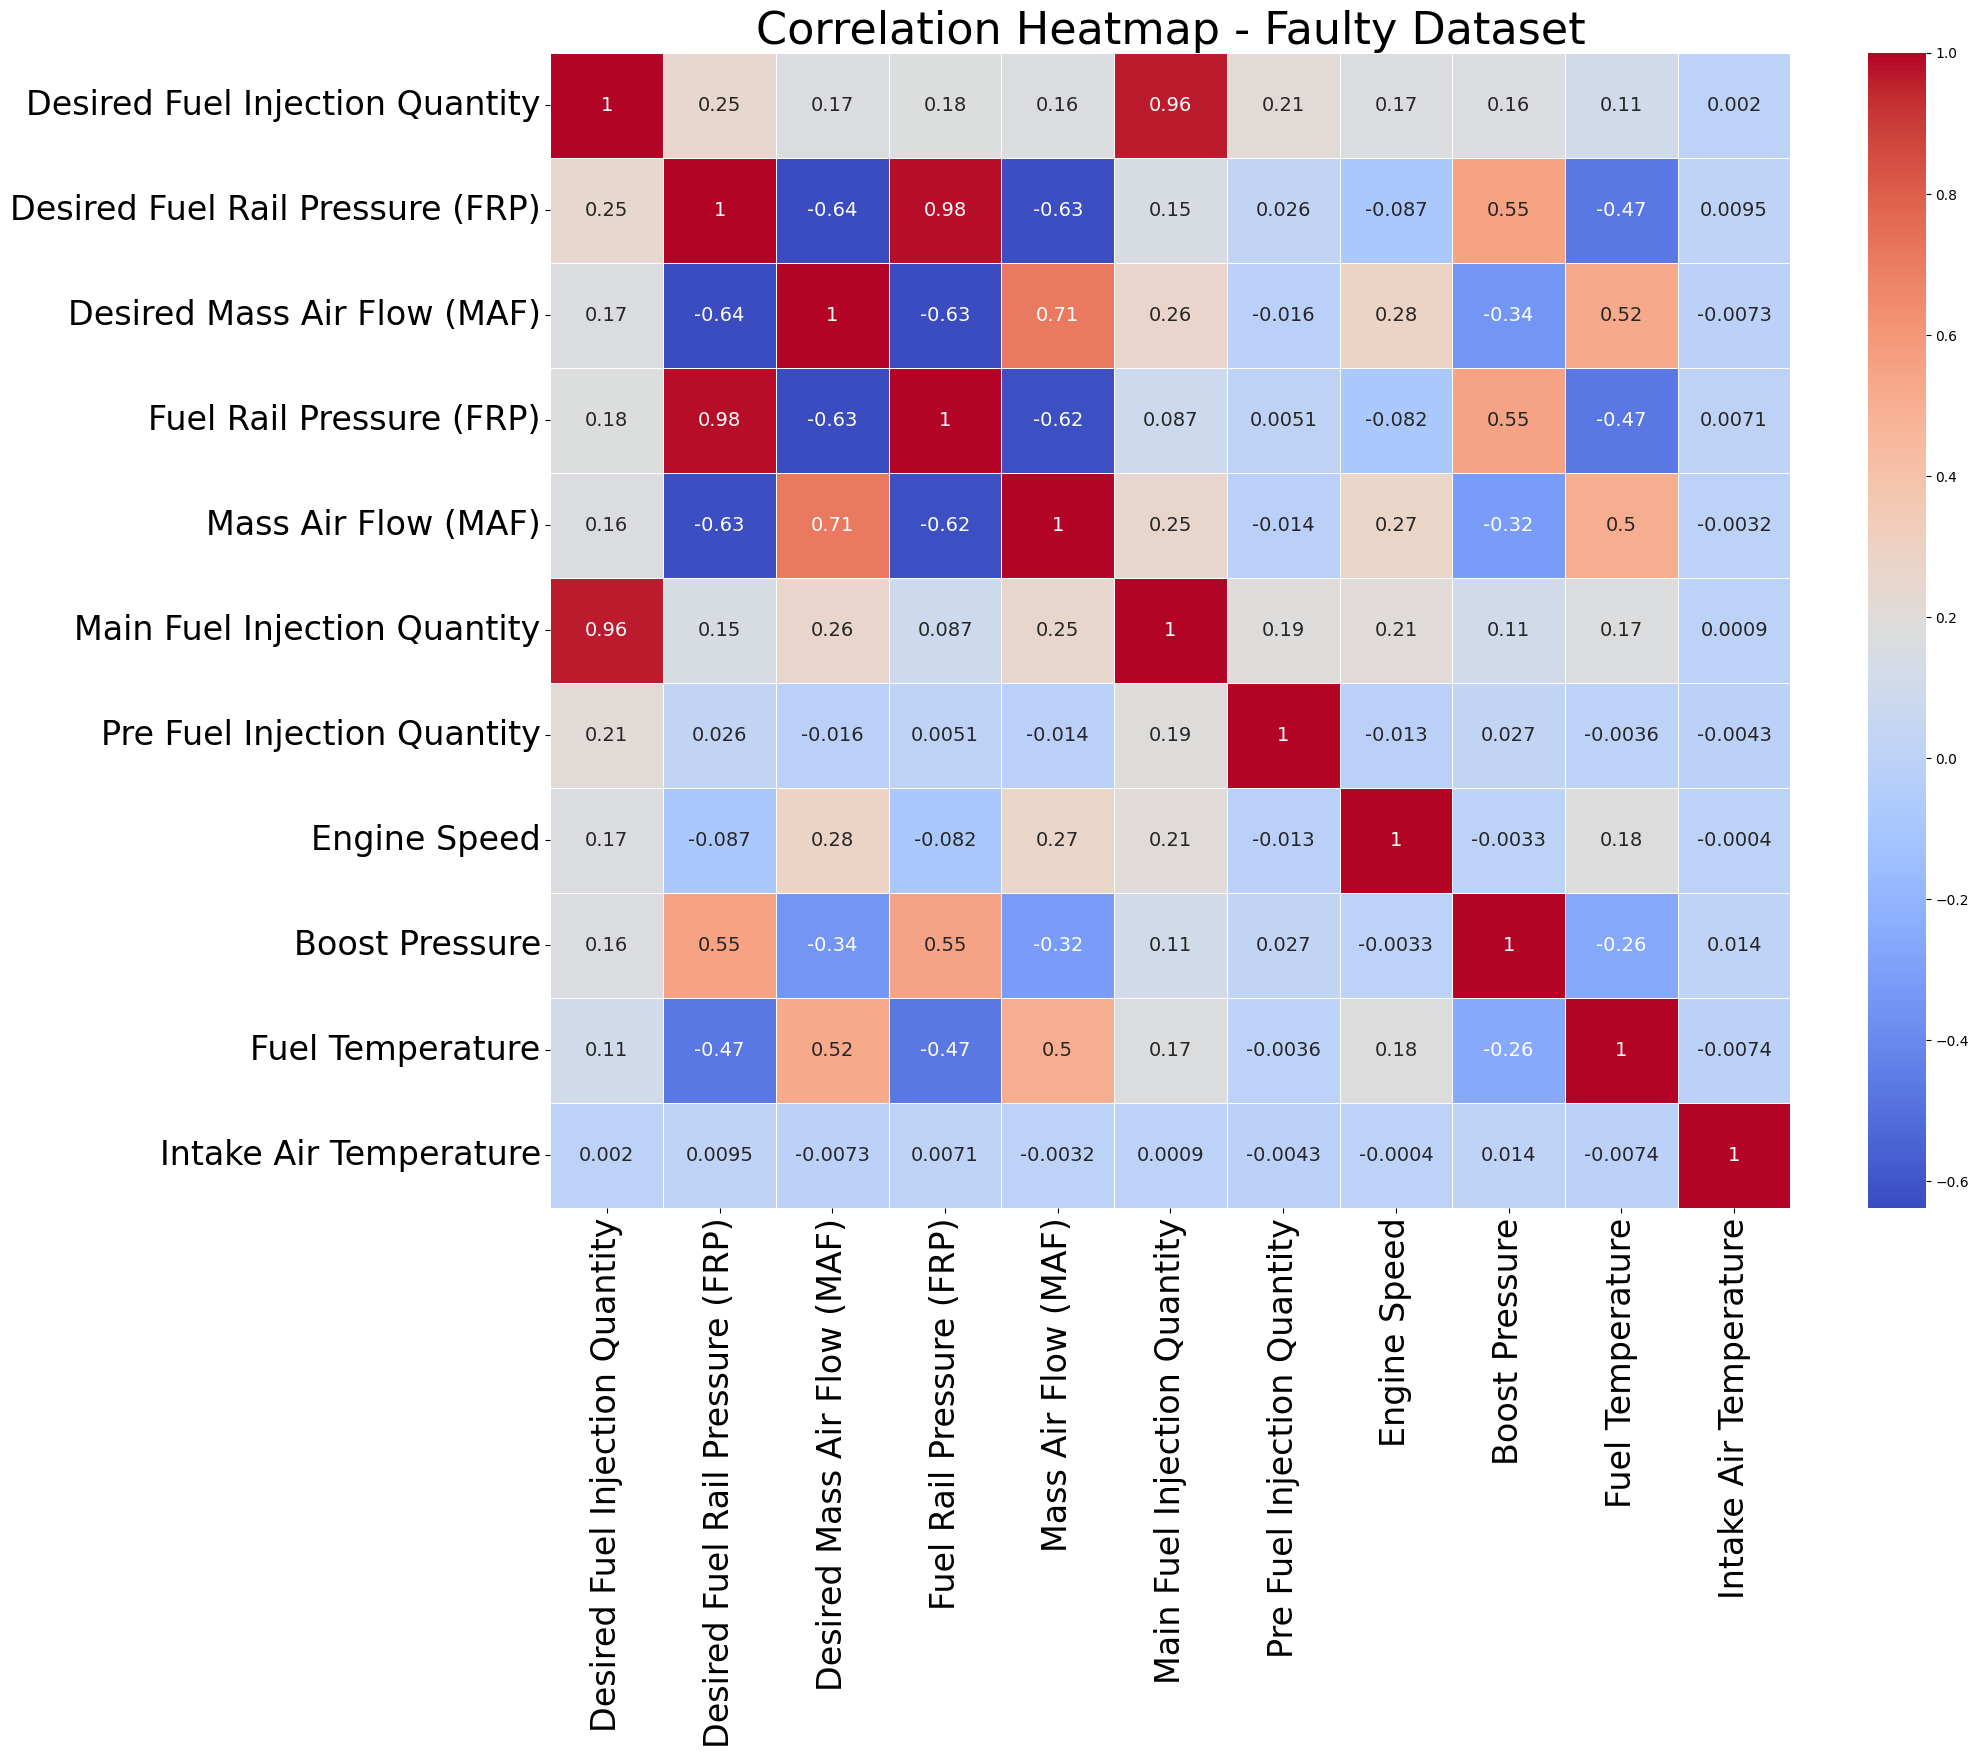

In [ ]:
# Plotting heatmap of important features for Faulty dataset (f_df)

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr_matrix_faulty = f_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix_faulty,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":14}
)

# Increase axis label size
plt.xticks(fontsize=24, rotation=90)
plt.yticks(fontsize=24)
plt.title("Correlation Heatmap - Faulty Dataset", fontsize=32)
plt.show()

In [ ]:
# ==============================
# Healthy dataset (h_df)
# ==============================
print("=== Healthy Dataset (h_df) ===")
print("Number of rows:", h_df.shape[0])
print("Number of columns:", h_df.shape[1])
print("\nColumn Names and Data Types:")
print(h_df.dtypes)
print("\nMissing Values per Column:")
print(h_df.isnull().sum())

# ==============================
# Faulty dataset (f_df)
# ==============================
print("\n\n=== Faulty Dataset (f_df) ===")
print("Number of rows:", f_df.shape[0])
print("Number of columns:", f_df.shape[1])
print("\nColumn Names and Data Types:")
print(f_df.dtypes)
print("\nMissing Values per Column:")
print(f_df.isnull().sum())

=== Healthy Dataset (h_df) ===
Number of rows: 26565
Number of columns: 10

Column Names and Data Types:
Desired Fuel Injection Quantity       int64
Desired Fuel Rail Pressure (FRP)    float64
Desired Mass Air Flow (MAF)         float64
Fuel Rail Pressure (FRP)            float64
Mass Air Flow (MAF)                 float64
Main Fuel Injection Quantity          int64
Pre Fuel Injection Quantity           int64
Engine Speed                          int64
Boost Pressure                        int64
classifier                            int64
dtype: object

Missing Values per Column:
Desired Fuel Injection Quantity     0
Desired Fuel Rail Pressure (FRP)    0
Desired Mass Air Flow (MAF)         0
Fuel Rail Pressure (FRP)            0
Mass Air Flow (MAF)                 0
Main Fuel Injection Quantity        0
Pre Fuel Injection Quantity         0
Engine Speed                        0
Boost Pressure                      0
classifier                          0
dtype: int64


=== Faulty Dataset